In [ ]:
from pathlib import Path
_p = Path.cwd()
steps = 0
while not (_p / "pyproject.toml").exists() and _p != _p.parent:
    _p = _p.parent
    steps += 1
print("gefunden nach", steps, "Schritten:", _p)

In [1]:
# Enable automatic reloading of modules before executing code
%load_ext autoreload
%autoreload 2

In [2]:
import os
import copy

from functools import partial, reduce

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import pingouin as pg
from PIL import Image

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor

import matplotlib.patches as patches
import matplotlib.colors as mcolors

from sentence_transformers import SentenceTransformer

In [3]:
import utils as ut

In [4]:
pd.set_option('display.max_columns', 100)

In [5]:
# test run of the model for dev purposes, or full/final data set?
is_testcase = False

# Load Model Results from Disk

In [6]:
l_data_subset = ["full"]
l_rnd_seed = [1]
l_embed_dim_full = [35]
modeltype = "free_weights_no_scaling"
modelversion = "embeddings-decision-combined-data"
l_id_weights = ["separate"]
l_lmbda = [1e-07]

# was the flag shared or separate set?
is_shared_separate = True

# load results from model run
l_results_full = ut.load_ID_lowdim_id_weights(
    l_data_subset=l_data_subset, l_rnd_seed=l_rnd_seed, l_lmbda=l_lmbda, l_id_weights_type=l_id_weights,
    l_embed_dim=l_embed_dim_full, modelversion=modelversion, modeltype=modeltype
)[0]

In [7]:
l_embed_dim_sh = [7]
l_rnd_seed = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
l_data_subset = ["first_half", "second_half"]

# load results from model run
l_results_splithalf = ut.load_ID_lowdim_id_weights(
    l_data_subset=l_data_subset, l_rnd_seed=l_rnd_seed, l_lmbda=l_lmbda, l_id_weights_type=l_id_weights,
    l_embed_dim=l_embed_dim_sh, modelversion=modelversion, modeltype=modeltype
)[0]


no results found in ./results/embeddings-decision-combined-data/modeltype_free_weights_no_scaling/7d/lmbda_1e-07/separate/seed10/data_subset_first_half
no results found in ./results/embeddings-decision-combined-data/modeltype_free_weights_no_scaling/7d/lmbda_1e-07/separate/seed10/data_subset_second_half
no results found in ./results/embeddings-decision-combined-data/modeltype_free_weights_no_scaling/7d/lmbda_1e-07/separate/seed11/data_subset_first_half
no results found in ./results/embeddings-decision-combined-data/modeltype_free_weights_no_scaling/7d/lmbda_1e-07/separate/seed11/data_subset_second_half


In [11]:
range_dims = l_embed_dim_sh

In [17]:
use_procrustes = True

partial_sims = partial(ut.dimensional_similarities, l_results_splithalf, use_procrustes=use_procrustes)
l_cors = list(map(partial_sims, l_embed_dim_sh))

dict_cors = {int(f'{range_dims[i]}'): sublist for i, sublist in enumerate(l_cors)}

partial_reorder = partial(ut.reorder_dimensions, l_results_splithalf, use_procrustes=use_procrustes)
l_max_sims = list(map(partial_reorder, range_dims))
dict_max_sims = dict(zip(range_dims, l_max_sims))

if use_procrustes:
    dict_idxs_use = ut.max_average_similarity_and_reliability(dict_cors, l_results_splithalf)
else:
    dict_idxs_use = ut.max_sim_dimensions_per_ndim(l_max_sims, range_dims)
dict_idxs_list_use = ut.max_sim_results_per_ndim(dict_idxs_use, dict_max_sims, range_dims)

if not use_procrustes:
    # no unique mapping for 15 dims, just use the first for visualizing
    dict_idxs_use[15] = 0
    dict_idxs_list_use[15] = [l_cors[len(range_dims) - 3][1][0], l_cors[len(range_dims) - 3][2][0]]
    dict_idxs_use[25] = 0
    dict_idxs_list_use[25] = [l_cors[len(range_dims) - 2][1][0], l_cors[len(range_dims) - 2][2][0]]
    dict_idxs_use[35] = 0
    dict_idxs_list_use[35] = [l_cors[len(range_dims) - 1][1][0], l_cors[len(range_dims) - 1][2][0]]

In [18]:
# Load Relevant IDs for correlational analyses
if is_testcase:
    df_pids = pd.read_csv("data/study1-2025-08/new-participant-ids-in-joint-modeling-testcase.csv")
elif not is_testcase:
    df_pids = pd.read_csv("data/study1-2025-08/new-participant-ids-in-joint-modeling.csv")

In [19]:
l_pids_model = list(df_pids["participant_id_model"])
l_pids_new = list(df_pids["participant_id_new"])

In [20]:
idx_full = 0
idx_h1 = dict_idxs_list_use[l_embed_dim_sh[0]][0]
idx_h2 = dict_idxs_list_use[l_embed_dim_sh[0]][1]

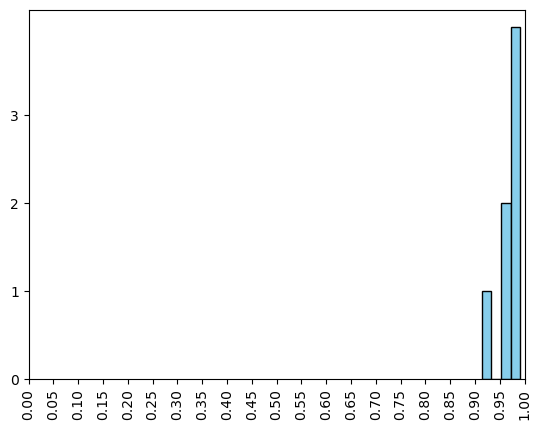

In [21]:
plt.hist(l_cors[0][0][dict_idxs_use[l_embed_dim_sh[0]]].max(axis=1), bins=4, color="skyblue", edgecolor="black")
plt.yticks(range(0, 4))
plt.xticks(np.linspace(0, 1, 21), rotation=90)
_ = plt.xlim((0, 1))

do this twice:
- first, only for the new batch of participants (i.e., 2025/08)
- then, for all available participants in the model (i.e., including THINGS participants), because we have age and gender for many of those as well

In [22]:
# new participants
df_dim_weights = ut.extract_dim_weight_results(l_results_full, idx_full, l_embed_dim_full[0], l_pids_model, l_pids_new)
df_dim_weights_h1 = ut.extract_dim_weight_results(l_results_splithalf, idx_h1, l_embed_dim_sh[0], l_pids_model, l_pids_new)
df_dim_weights_h2 = ut.extract_dim_weight_results(l_results_splithalf, idx_h2, l_embed_dim_sh[0], l_pids_model, l_pids_new)
df_dim_weights, colnames_dim_weights_full = ut.rename_dim_weight_cols(df_dim_weights, l_embed_dim_full[0])
df_dim_weights_h1, colnames_dim_weights_sh = ut.rename_dim_weight_cols(df_dim_weights_h1, l_embed_dim_sh[0])
df_dim_weights_h2, _ = ut.rename_dim_weight_cols(df_dim_weights_h2, l_embed_dim_sh[0])

In [23]:
# THINGS participants
df_things_participants = pd.read_csv("data/THINGS-demographic-lookup.csv")
df_things_participants.rename(
    columns={"subject_id":"participant_id_model", "subject_id_THINGS": "participant_id_THINGS"},
    inplace=True
)
df_things_participants["participant_id_new"] = np.nan
df_things_participants['gender_num'] = df_things_participants['gender'].apply(
    lambda x: 0 if x == "male" else 1 if x == "female" else 2
)
df_things_participants.drop(columns=["gender", "participant_id_THINGS", "n"], inplace=True)
# same naming as in new data
df_things_participants.rename(
    columns={"gender_num":"Sex_0", "mn_age":"age", "mn_RT": "rt", "participant_id_new": "pid"},
    inplace=True)
df_things_participants.head()

l_pids_model_THINGS = df_things_participants["participant_id_model"].tolist()
l_pids_model_THINGS_new = df_things_participants["pid"].tolist()

df_dim_weights_THINGS = ut.extract_dim_weight_results(l_results_full, idx_full, l_embed_dim_full[0], l_pids_model_THINGS, l_pids_model_THINGS_new)
df_dim_weights_h1_THINGS = ut.extract_dim_weight_results(l_results_splithalf, idx_h1, l_embed_dim_sh[0], l_pids_model_THINGS, l_pids_model_THINGS_new)
df_dim_weights_h2_THINGS = ut.extract_dim_weight_results(l_results_splithalf, idx_h2, l_embed_dim_sh[0], l_pids_model_THINGS, l_pids_model_THINGS_new)
df_dim_weights_THINGS, _ = ut.rename_dim_weight_cols(df_dim_weights_THINGS, l_embed_dim_full[0])
df_dim_weights_h1_THINGS, _ = ut.rename_dim_weight_cols(df_dim_weights_h1_THINGS, l_embed_dim_sh[0])
df_dim_weights_h2_THINGS, _ = ut.rename_dim_weight_cols(df_dim_weights_h2_THINGS, l_embed_dim_sh[0])

In [24]:
# load dfs saved with R (after applying exclusion criteria)
df_qs_num_long = pd.read_csv("data/study1-2025-08/tbl_qs_num_long_excluded.csv")
df_qs_txt = pd.read_csv("data/study1-2025-08/tbl_qs_txt_excluded.csv")
df_qs_num = df_qs_num_long.pivot(index=["participant_id", "session_id"], columns="name", values="value").reset_index(drop=False)

In [25]:
# read average RT per participant
df_avg = pd.read_csv("data/study1-2025-08/avg-rt.csv")

In [26]:
df_qs_num = pd.merge(df_qs_num.drop(columns=["rt"]), df_avg.drop(columns=["participant_id_model"]), how="left", on="participant_id")
df_qs_num.rename(columns={"mn_rt":"rt"}, inplace=True)

In [27]:
# reverse code items
df_qs_num = ut.reverse_code_q_items(df_qs_num)
# create scale and facet scores
df_qs_num = ut.scales_and_facets(df_qs_num)
# only keep scales, drop items and facets
df_qs_num = ut.keep_scales_only(df_qs_num)
df_qs_num.drop(columns=["diagnosis_2", "meds_3", "attention_2", "rwn"], inplace=True)

In [28]:
df_qs_num["Sex_0"].value_counts()

Sex_0
1.0    99
0.0    98
2.0     1
Name: count, dtype: int64

In [29]:
df_things_participants["Sex_0"].value_counts()

Sex_0
1    451
0    268
2     60
Name: count, dtype: int64

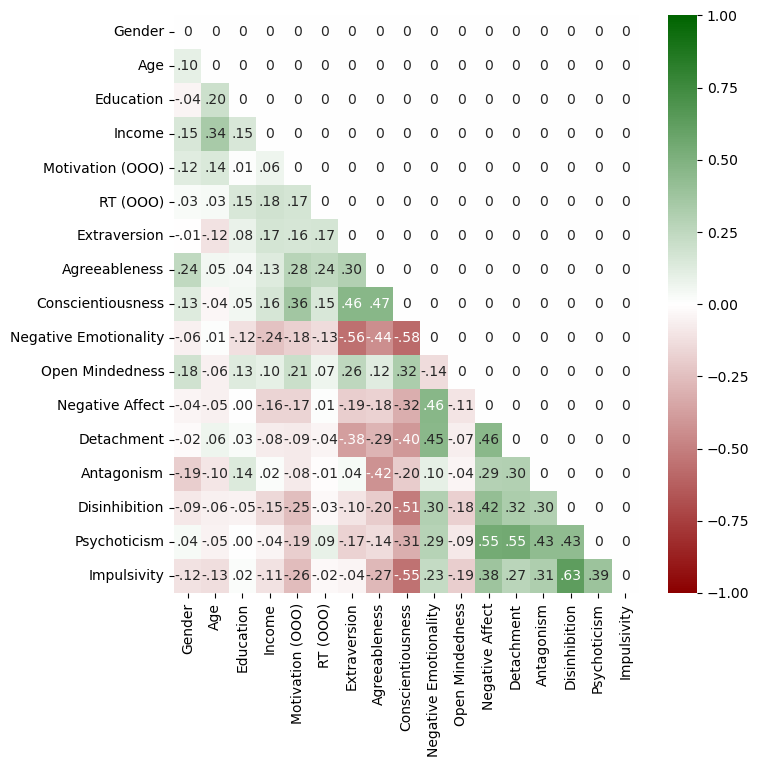

In [30]:
df_hm = df_qs_num.copy()
df_hm.drop(columns = ["participant_id", "session_id", "idx"], inplace=True)
df_hm.rename(
    columns={
        "Sex_0":"Gender", "age":"Age", "edu":"Education", 
        "income_0":"Income", "motivation_1":"Motivation (OOO)",
        "rt":"RT (OOO)", "Negative_Emotionality":"Negative Emotionality",
        "Open_Mindedness":"Open Mindedness"
}, inplace=True)

f, ax = plt.subplots(1, figsize=(7.5, 7.5))

# Create custom diverging colormap
cmap = mcolors.LinearSegmentedColormap.from_list("custom_diverging", ["darkred", "white", "darkgreen"] )
norm = mcolors.TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)

def no_leading_zero(x):
    if x == 0:
        return "0"
    elif x == 1:
        return "1"
    elif pd.isna(x):
        return ""
    s = f"{x:.2f}" # format number
    s = s.replace("-0.", "-.") # -0.34 → -.34
    s = s.replace("0.", ".") # 0.34 → .34
    return s

df_hm_plot = pd.DataFrame(np.tril(np.corrcoef(df_hm.transpose()), k=-1))
df_hm_plot.columns = df_hm.columns
df_hm_plot.index = df_hm.columns
_ = sns.heatmap(
    df_hm_plot, annot=df_hm_plot.map(no_leading_zero), # formatted annotations
    fmt="", # required when passing strings
    ax=ax, cmap=cmap, norm=norm
)

In [25]:
df_qs_txt["workHistory"] = df_qs_txt["workHistory"].fillna("[UNK]")
df_qs_txt["interests1"] = df_qs_txt["interests1"].fillna("[UNK]")
df_qs_txt["interests2"] = df_qs_txt["interests2"].fillna("[UNK]")
df_qs_txt["interests3"] = df_qs_txt["interests3"].fillna("[UNK]")

In [26]:
df_qs_txt = ut.add_prefixes_and_concatenate_cols(df_qs_txt)

model_id = "answerdotai/ModernBERT-base"
model, tokenizer, device = ut.load_ll_model(model_id)

df_qs_txt["embedding_work_history"] = df_qs_txt["workHistory"].apply(
    lambda col: ut.tokenize_col(
        col, prefix1 = "Here are some details about my life: ", 
        prefix2 = "I have worked as ", 
        tokenizer=tokenizer, model=model, device=device
    )
)
df_qs_txt["embedding_interests1"] = df_qs_txt["interests1"].apply(
    lambda col: ut.tokenize_col(
        col, prefix1 = "Here are some details about my life: ", 
        prefix2 = "The topics or activities I am most passionate about are: ", 
        tokenizer=tokenizer, model=model, device=device
    )
)
df_qs_txt["embedding_interests2"] = df_qs_txt["interests2"].apply(
    lambda col: ut.tokenize_col(
        col, prefix1 = "Here are some details about my life: ", 
        prefix2 = "The topics or activities I love doing in my free time are: ", 
        tokenizer=tokenizer, model=model, device=device
    )
)
df_qs_txt["embedding_interests3"] = df_qs_txt["interests3"].apply(
    lambda col: ut.tokenize_col(
        col, prefix1 = "Here are some details about my life: ", 
        prefix2 = "The subjects, which fascinate me and make me want to learn more are: ", 
        tokenizer=tokenizer, model=model, device=device
    )
)
df_qs_txt["embedding_all_txt"] = df_qs_txt["txt_concat"].apply(
    lambda col: ut.tokenize_col(col, prefix1 = "", prefix2 = "", tokenizer=tokenizer, model=model, device=device)
)

In [27]:
# Load the model
model = SentenceTransformer('intfloat/multilingual-e5-large')
df_qs_txt["embedding_work_history"] = df_qs_txt["workHistory"].apply(
    lambda col: ut.embed_qwen(
        col, prefix1 = "Here are some details about my life: ", 
        prefix2 = "I have worked as ",  model=model
    )
)
df_qs_txt["embedding_interests1"] = df_qs_txt["interests1"].apply(
    lambda col: ut.embed_qwen(
        col, prefix1 = "Here are some details about my life: ", 
        prefix2 = "The topics or activities I am most passionate about are: ", model=model
    )
)
df_qs_txt["embedding_interests2"] = df_qs_txt["interests2"].apply(
    lambda col: ut.embed_qwen(
        col, prefix1 = "Here are some details about my life: ", 
        prefix2 = "The topics or activities I love doing in my free time are: ", model=model
    )
)
df_qs_txt["embedding_interests3"] = df_qs_txt["interests3"].apply(
    lambda col: ut.embed_qwen(
        col, prefix1 = "Here are some details about my life: ", 
        prefix2 = "The subjects, which fascinate me and make me want to learn more are: ", model=model
    )
)
df_qs_txt["embedding_all_txt"] = df_qs_txt["txt_concat"].apply(
    lambda col: ut.embed_qwen(col, prefix1 = "", prefix2 = "", model=model)
)

In [29]:
idx_embeddings = [col.startswith("embedding") for col in df_qs_txt.columns]
colnames_required = list(df_qs_txt.columns[idx_embeddings])

colnames_required.extend(["participant_id", "session_id"])
df_embeddings = df_qs_txt[colnames_required]
df_qs_num = df_qs_num.merge(df_embeddings, how="left", on=["participant_id", "session_id"])

In [30]:
df_ooo_qs = df_dim_weights.merge(df_qs_num, how="left", left_on="participant_id_new", right_on="participant_id")
# rename participant id col
df_ooo_qs.rename(columns={"participant_id_new":"pid"}, inplace=True)
df_dim_weights_h1.rename(columns={"participant_id_new":"pid"}, inplace=True)
df_dim_weights_h2.rename(columns={"participant_id_new":"pid"}, inplace=True)

In [31]:
def weights_delta_gini(df_h1, df_h2, df_to_merge_in, pid_str):
    
    # absolute sum of deltas of dimensional weights between halves
    df_both_halves = pd.merge(df_h1, df_h2, how="left", on=pid_str, suffixes=["_h1", "_h2"])
    for cn in colnames_dim_weights_sh:
        df_both_halves[f"""{cn}_delta"""] = df_both_halves[f"""{cn}_h2"""] - df_both_halves[f"""{cn}_h1"""]
    df_both_halves["delta_abs_sum"] = np.sum(np.abs(df_both_halves[[c + "_delta" for c in colnames_dim_weights_sh]]), axis=1)
    # assign to omnibus df
    df_to_merge_in["weights_delta_abs_sum"] = df_both_halves["delta_abs_sum"]
    
    # gini coef on distribution of weights
    df_gini = df_to_merge_in[[pid_str] + colnames_dim_weights_sh].melt(id_vars=pid_str, value_name="weight", var_name="dimension")
    ginis = df_gini.groupby(pid_str)[["weight"]].agg(ut.gini).reset_index()
    ginis.columns = [pid_str, "gini_overall"]
    
    # gini coef on distribution of change of weights (i.e., same features weighted similarly across split halfs?)
    df_gini_all, icc_ginis = ut.gini_of_halves(df_both_halves, ginis, colnames_dim_weights_sh, pid_str)
    
    # and merge ginis again with omnibus df
    df_to_merge_in = pd.merge(df_to_merge_in, df_gini_all, how="left", on=pid_str)

    return df_to_merge_in

In [32]:
df_ooo_qs = weights_delta_gini(df_dim_weights_h1, df_dim_weights_h2, df_ooo_qs, "pid")
df_dim_weights_h1_THINGS.rename(columns={"participant_id_new":"pid"}, inplace=True)
df_dim_weights_h2_THINGS.rename(columns={"participant_id_new":"pid"}, inplace=True)
df_dim_weights_THINGS.rename(columns={"participant_id_new":"pid"}, inplace=True)
df_dim_weights_THINGS = weights_delta_gini(df_dim_weights_h1_THINGS, df_dim_weights_h2_THINGS, df_dim_weights_THINGS, "participant_id_model")

In [33]:
df_dim_weights_THINGS = pd.merge(df_dim_weights_THINGS, df_things_participants, how="left", on=["participant_id_model", "pid"])

In [34]:
df_ooo_qs.query("Sex_0 in (0, 1)", inplace=True)

In [35]:
df_ooo_qs["age_bin"] = pd.cut(df_ooo_qs["age"], bins=[0, 21, 30, 59, 70], labels=False)

In [36]:
df_ooo_qs.columns

Index(['pid', 'participant_id_model', 'dim1', 'dim2', 'dim3', 'dim4', 'dim5',
       'dim6', 'dim7', 'dim8', 'dim9', 'dim10', 'dim11', 'dim12', 'dim13',
       'dim14', 'dim15', 'dim16', 'dim17', 'dim18', 'dim19', 'dim20', 'dim21',
       'dim22', 'dim23', 'dim24', 'dim25', 'dim26', 'dim27', 'dim28', 'dim29',
       'dim30', 'dim31', 'dim32', 'dim33', 'dim34', 'dim35', 'avg_weight',
       'participant_id', 'session_id', 'Sex_0', 'age', 'edu', 'idx',
       'income_0', 'motivation_1', 'rt', 'Extraversion', 'Agreeableness',
       'Conscientiousness', 'Negative_Emotionality', 'Open_Mindedness',
       'Negative Affect', 'Detachment', 'Antagonism', 'Disinhibition',
       'Psychoticism', 'Impulsivity', 'embedding_work_history',
       'embedding_interests1', 'embedding_interests2', 'embedding_interests3',
       'embedding_all_txt', 'weights_delta_abs_sum', 'gini_overall',
       'gini_first_half', 'gini_second_half', 'gini_delta', 'age_bin'],
      dtype='object')

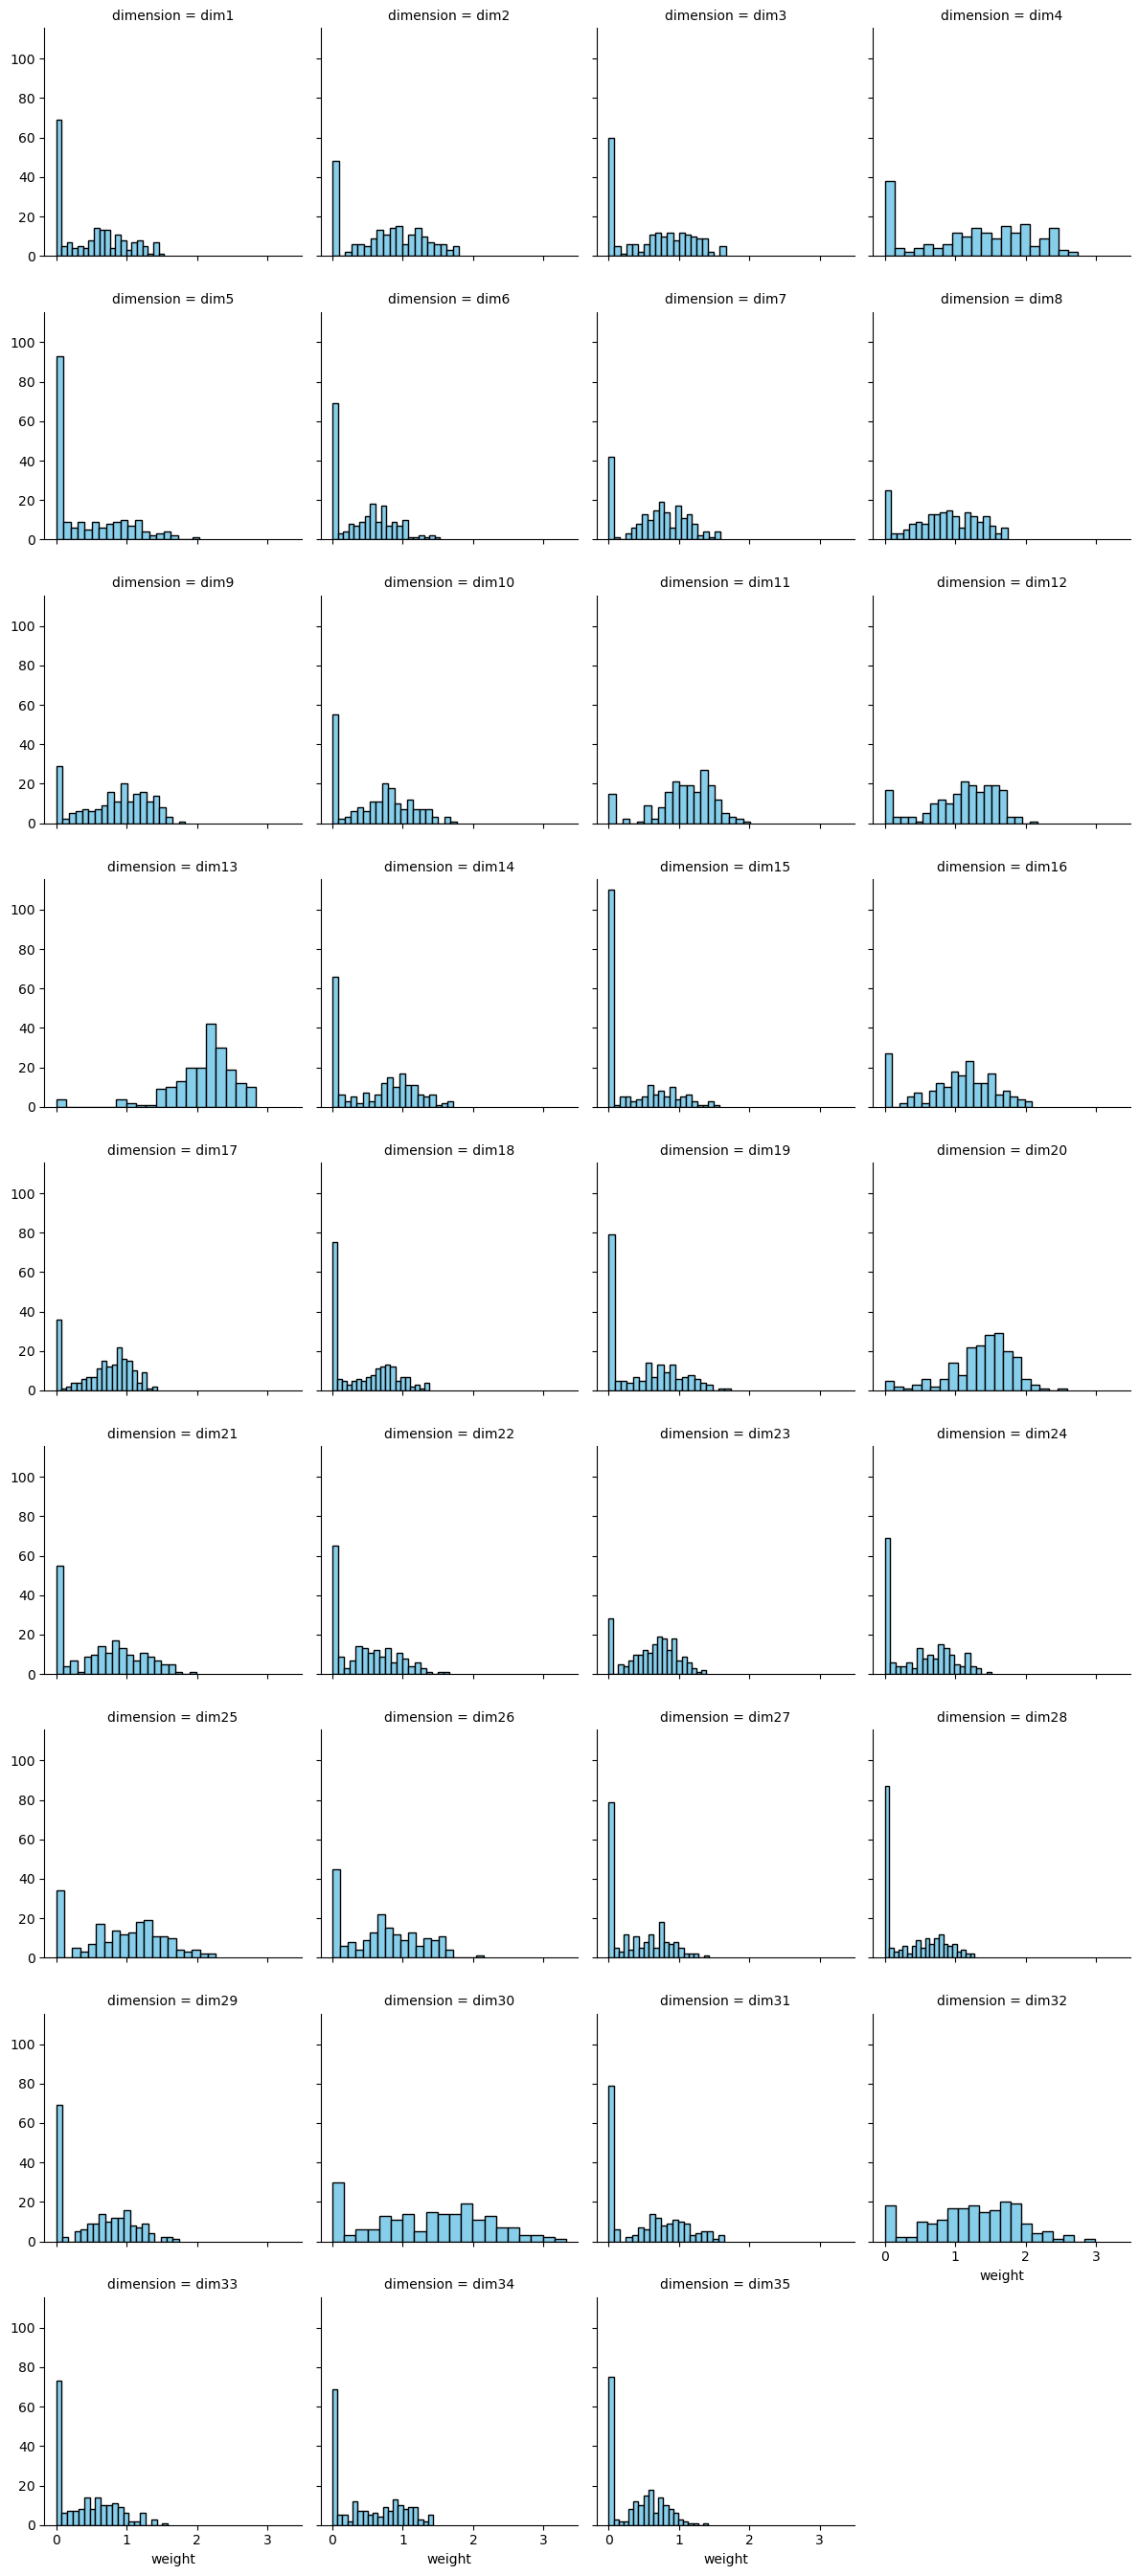

In [37]:
df_dims_long = df_ooo_qs[["pid"] + colnames_dim_weights_full].melt(id_vars="pid", var_name="dimension", value_name="weight")
g = sns.FacetGrid(data=df_dims_long, col="dimension", col_wrap=4)
_ = g.map(plt.hist, "weight", bins=20, color="skyblue", edgecolor="black")

In [38]:
cols_corr_new = ['edu', 'income_0', 'motivation_1', "idx",
       'Extraversion', 'Agreeableness', 'Conscientiousness',
       'Negative_Emotionality', 'Open_Mindedness', 'Negative Affect',
       'Detachment', 'Antagonism', 'Disinhibition', 'Psychoticism',
       'Impulsivity']
cols_corr_combined = ["age", "Sex_0", "rt"]

In [39]:
from scipy.stats import pearsonr

In [40]:
def corr_weight(col_str, col_str_fixed, df_cor):
    x=df_cor[col_str]
    y=df_cor[col_str_fixed]
    mask = ~np.isnan(x) & ~np.isnan(y)
    x_clean = x[mask]
    y_clean = y[mask]
    corcoef, pval = pearsonr(x_clean, y_clean)
    return corcoef, pval

In [41]:
f_partial = partial(corr_weight, col_str_fixed = "avg_weight", df_cor = df_ooo_qs)
l_cors_weight = list(map(f_partial, cols_corr_new))
df_corr_weight = pd.DataFrame({"var":cols_corr_new, "r":[float(c[0]) for c in l_cors_weight], "pval":[float(c[1]) for c in l_cors_weight]})
df_corr_weight_new = df_corr_weight.sort_values("r", ascending=False).reset_index(drop=True)

f_partial = partial(corr_weight, col_str_fixed = "weights_delta_abs_sum", df_cor = df_ooo_qs)
l_cors_weight_change = list(map(f_partial, cols_corr_new))
df_corr_weight_change = pd.DataFrame({"var":cols_corr_new, "r":[float(c[0]) for c in l_cors_weight_change], "pval":[float(c[1]) for c in l_cors_weight_change]})
df_corr_weight_change_new = df_corr_weight_change.sort_values("r", ascending=False).reset_index(drop=True)

f_partial = partial(corr_weight, col_str_fixed = "gini_overall", df_cor = df_ooo_qs)
l_cors_gini = list(map(f_partial, cols_corr_new))
df_corr_gini = pd.DataFrame({"var":cols_corr_new, "r":[float(c[0]) for c in l_cors_gini], "pval":[float(c[1]) for c in l_cors_gini]})
df_corr_gini_new = df_corr_gini.sort_values("r", ascending=False).reset_index(drop=True)

In [42]:
df_corr_weight_new

,var,r,pval
0,Negative_Emotionality,0.158035,0.026557
1,motivation_1,0.146747,0.039615
2,Detachment,0.122411,0.086595
3,edu,0.086398,0.227357
4,idx,0.078918,0.270315
5,Psychoticism,0.066977,0.349720
6,Negative Affect,0.043033,0.548219
7,Open_Mindedness,0.001705,0.981034
8,Impulsivity,-0.027711,0.699099
9,Antagonism,-0.028347,0.692536


In [43]:
df_dim_weights_THINGS.query("Sex_0 in (0, 1) and ~age.isna()", inplace=True)

In [44]:
df_weights_combined = pd.concat([
    df_dim_weights_THINGS, df_ooo_qs.loc[:,df_dim_weights_THINGS.columns]
])

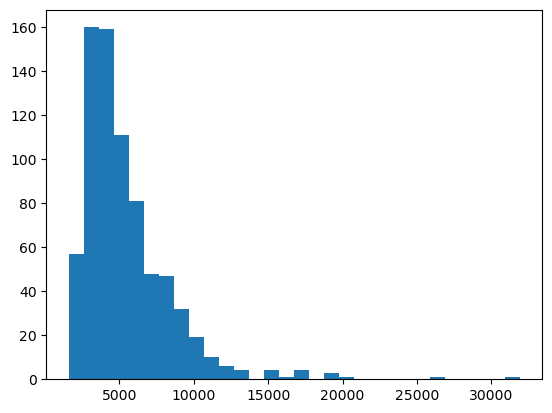

In [45]:
_ = plt.hist(x=df_weights_combined["rt"], bins=30)

In [46]:
df_weights_combined.loc[df_weights_combined["rt"] > 15000, "rt"] = np.nan

In [47]:
f_partial = partial(corr_weight, col_str_fixed = "avg_weight", df_cor = df_weights_combined)
l_cors_weight = list(map(f_partial, cols_corr_combined))
df_corr_weight = pd.DataFrame({"var":cols_corr_combined, "r":[float(c[0]) for c in l_cors_weight], "pval":[float(c[1]) for c in l_cors_weight]})
df_corr_weight_all = df_corr_weight.sort_values("r", ascending=False).reset_index(drop=True)

f_partial = partial(corr_weight, col_str_fixed = "weights_delta_abs_sum", df_cor = df_weights_combined)
l_cors_weight_change = list(map(f_partial, cols_corr_combined))
df_corr_weight_change = pd.DataFrame({"var":cols_corr_combined, "r":[float(c[0]) for c in l_cors_weight_change], "pval":[float(c[1]) for c in l_cors_weight_change]})
df_corr_weight_change_all = df_corr_weight_change.sort_values("r", ascending=False).reset_index(drop=True)

f_partial = partial(corr_weight, col_str_fixed = "gini_overall", df_cor = df_weights_combined)
l_cors_gini = list(map(f_partial, cols_corr_combined))
df_corr_gini = pd.DataFrame({"var":cols_corr_combined, "r":[float(c[0]) for c in l_cors_gini], "pval":[float(c[1]) for c in l_cors_gini]})
df_corr_gini_all = df_corr_gini.sort_values("r", ascending=False).reset_index(drop=True)

In [48]:
df_corr_weight = pd.concat([df_corr_weight_new, df_corr_weight_all]).sort_values("pval")
df_corr_weight_change = pd.concat([df_corr_weight_change_new, df_corr_weight_change_all]).sort_values("pval")
df_corr_gini = pd.concat([df_corr_gini_new, df_corr_gini_all]).sort_values("pval")

In [49]:
df_corr_weight.query("pval <= .08")

,var,r,pval
0,Sex_0,0.150586,0.000035
14,Extraversion,-0.174833,0.014001
0,Negative_Emotionality,0.158035,0.026557
1,motivation_1,0.146747,0.039615
2,rt,-0.074412,0.043580
1,age,0.073219,0.045158
13,income_0,-0.140448,0.049009


In [50]:
df_corr_weight_change.query("pval <= 0.08")

,var,r,pval


In [51]:
df_corr_gini.query("pval <= 0.08")

,var,r,pval
0,rt,0.116207,0.001589
2,Sex_0,-0.111788,0.002185
1,age,-0.110200,0.002527
0,Agreeableness,0.139340,0.050840
14,Negative_Emotionality,-0.125421,0.079070


In [52]:
def my_pearsonr(x, y, my_df):
    r = pearsonr(my_df[x], my_df[y])
    dict_r = {"r":r[0], "pvalue":r[1], "Dimension":x, "Variable":y}
    return dict_r

def max_corr_dimweights(l_col, my_df):
    pearsonr_partial = partial(my_pearsonr, y = l_col, my_df=my_df)
    l_cors = list(map(pearsonr_partial, colnames_dim_weights_full))
    return l_cors

In [53]:
partial_maxcorr = partial(max_corr_dimweights, my_df = df_ooo_qs)
l_max_corrs_new = list(map(partial_maxcorr, ["motivation_1", "edu"]))

partial_maxcorr = partial(max_corr_dimweights, my_df = df_weights_combined)
l_max_corrs_all = list(map(partial_maxcorr, ["age", "Sex_0"]))

In [54]:
df_max_corrs_new = reduce(lambda x, y: pd.concat([x, y], ignore_index=True),
            [pd.DataFrame.from_dict(d) for d in l_max_corrs_new])
df_max_corrs_all = reduce(lambda x, y: pd.concat([x, y], ignore_index=True),
            [pd.DataFrame.from_dict(d) for d in l_max_corrs_all])
df_max_corrs = pd.concat([df_max_corrs_new, df_max_corrs_all])
# Sample renaming dictionary
rename_dict = {
    "motivation_1": "Motivation (Self Report)",
    "edu": "Years Education",
    "age": "Age",
    "Sex_0": "Gender (1: Women)"
}

# Apply renaming
df_max_corrs["Variable"] = df_max_corrs["Variable"].replace(rename_dict)

In [55]:
def rename_col_for_plot(my_df):
    my_df.loc[my_df["var"] == "motivation_1", "var"] = "Motivation (Self Report)"
    my_df.loc[my_df["var"] == "age", "var"] = "Age"
    my_df.loc[my_df["var"] == "edu", "var"] = "Years Education"
    my_df.loc[my_df["var"] == "Sex_0", "var"] = "Gender (1: Women)"

    return my_df

In [56]:
df_corr_weight = rename_col_for_plot(df_corr_weight)
df_corr_weight_change = rename_col_for_plot(df_corr_weight_change)
df_corr_gini = rename_col_for_plot(df_corr_gini)

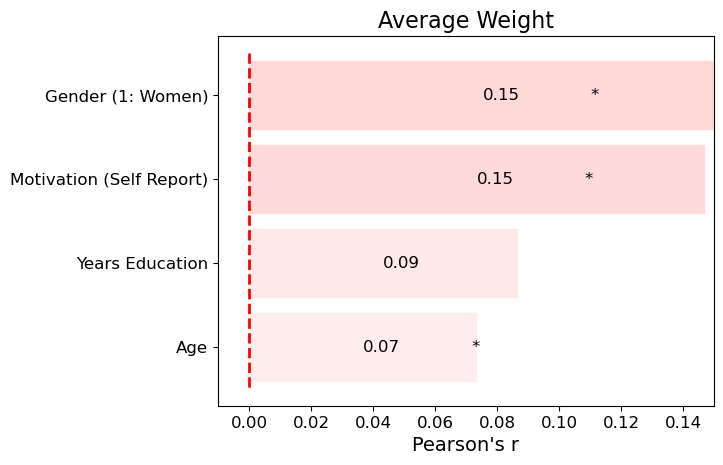

In [57]:
f, ax = plt.subplots(1)

cmap = mcolors.LinearSegmentedColormap.from_list("rwr", ["red", "white", "red"])
norm = mcolors.Normalize(vmin=-1, vmax=1)
df_corr_weight["color"] = df_corr_weight["r"].map(lambda x: cmap(norm(x)))

# subset hypotheses:
df_plt = df_corr_weight.query("var in ('Motivation (Self Report)', 'Age', 'Years Education', 'Gender (1: Women)')").sort_values("r", ascending=False)

# Plot the barplot without specifying color
barplot = sns.barplot(data=df_plt, x="r", y="var", ax=ax)


# Apply individual colors to each bar
for bar, color, r, pval in zip(barplot.patches, df_plt["color"], df_plt["r"], df_plt["pval"]):
    bar.set_color(color)
    ax.text(
        bar.get_width() / 2,                      # x-position
        bar.get_y() + bar.get_height() / 2,   # y-position
        f"{r:.2f}",                       # label text
        va='center', ha='left', fontsize=12  # alignment and style
    )
    if pval <= 0.05:
        ax.text(
            bar.get_width() / 2 + .035,                      # x-position
            bar.get_y() + bar.get_height() / 2,   # y-position
            "*",                       # label text
            va='center', ha='left', fontsize=12    # alignment and style
        )

ax.set_title("Average Weight", fontsize=16)
ax.set_xlabel("Pearson's r", fontsize=14)
ax.set_ylabel("", fontsize=14)
ax.tick_params(axis='both', labelsize=12)
ax.vlines(x=0,ymin=-0.5,ymax=3.5, color="red", linewidth=2, linestyle="--")
_ = ax.set_xlim((-0.01, 0.15))

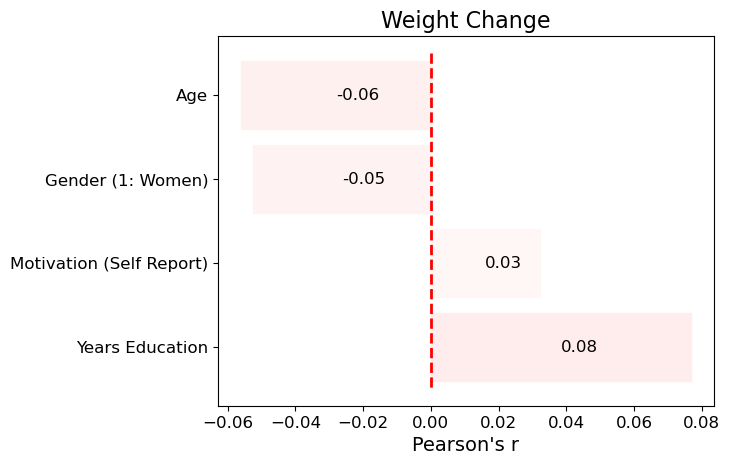

In [58]:
f, ax = plt.subplots(1)

cmap = mcolors.LinearSegmentedColormap.from_list("rwr", ["red", "white", "red"])
norm = mcolors.Normalize(vmin=-1, vmax=1)
df_corr_weight_change["color"] = df_corr_weight_change["r"].map(lambda x: cmap(norm(x)))


df_plt = df_corr_weight_change.query("var in ('Motivation (Self Report)', 'Age', 'Years Education', 'Gender (1: Women)')").sort_values("r")
# Plot the barplot without specifying color
barplot = sns.barplot(data=df_plt, x="r", y="var", ax=ax)


# Apply individual colors to each bar
for bar, color, r, pval in zip(barplot.patches, df_plt["color"], df_plt["r"], df_plt["pval"]):
    bar.set_color(color)
    ax.text(
        bar.get_width() / 2,                      # x-position
        bar.get_y() + bar.get_height() / 2,   # y-position
        f"{r:.2f}",                       # label text
        va='center', ha='left', fontsize=12    # alignment and style
    )
    if pval <= 0.05:
        ax.text(
            bar.get_width() / 2 + .035,                      # x-position
            bar.get_y() + bar.get_height() / 2,   # y-position
            "*",                       # label text
            va='center', ha='left', fontsize=12    # alignment and style
        )
ax.vlines(x=0,ymin=-0.5,ymax=3.5, color="red", linewidth=2, linestyle="--")
ax.set_title("Weight Change", fontsize=16)
ax.set_title(ax.get_title(), fontsize=16)
ax.set_xlabel("Pearson's r", fontsize=14)
ax.set_ylabel("", fontsize=14)
_ = ax.tick_params(axis='both', labelsize=12)

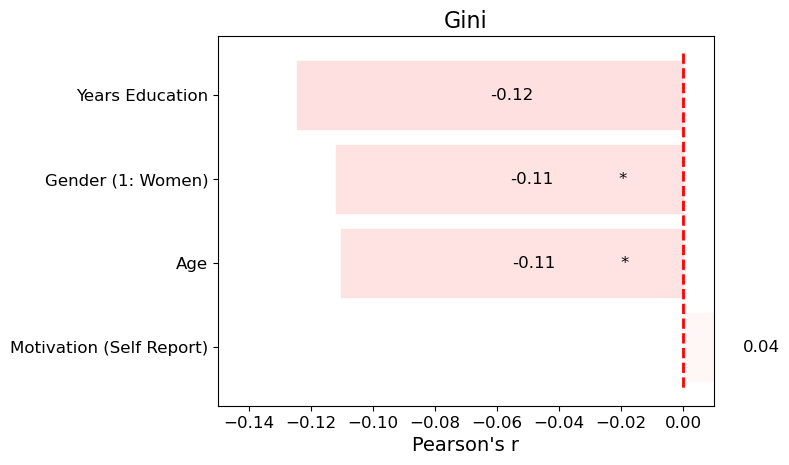

In [59]:
f, ax = plt.subplots(1)

cmap = mcolors.LinearSegmentedColormap.from_list("rwr", ["red", "white", "red"])
norm = mcolors.Normalize(vmin=-1, vmax=1)
df_corr_gini["color"] = df_corr_gini["r"].map(lambda x: cmap(norm(x)))


# subset hypotheses:
df_plt = df_corr_gini.query("var in ('Motivation (Self Report)', 'Age', 'Years Education', 'Gender (1: Women)')").sort_values("r")


# Plot the barplot without specifying color
barplot = sns.barplot(data=df_plt, x="r", y="var", ax=ax)



# Apply individual colors to each bar
for bar, color, r, pval in zip(barplot.patches, df_plt["color"], df_plt["r"], df_plt["pval"]):
    bar.set_color(color)
    ax.text(
        bar.get_width() / 2,                      # x-position
        bar.get_y() + bar.get_height() / 2,   # y-position
        f"{r:.2f}",                       # label text
        va='center', ha='left', fontsize=12    # alignment and style
    )
    if pval <= 0.05:
        ax.text(
            bar.get_width() / 2 + .035,                      # x-position
            bar.get_y() + bar.get_height() / 2,   # y-position
            "*",                       # label text
            va='center', ha='left', fontsize=12    # alignment and style
        )


ax.set_title("Gini", fontsize=16)
ax.set_xlabel("Pearson's r", fontsize=14)
ax.set_ylabel("", fontsize=14)
ax.tick_params(axis='both', labelsize=12)
ax.vlines(x=0,ymin=-0.5,ymax=3.5, color="red", linewidth=2, linestyle="--")
_ = ax.set_xlim((-0.15, 0.01))

In [60]:
df_icc = df_weights_combined.melt(id_vars=["participant_id_model"], value_vars=["dim1", "dim2", "dim3", "dim4", "dim5", "dim6", "dim7"], var_name="dimension", value_name="decision_weight")
df_icc.columns = ["id", "dimension", "decision_weight"]

In [61]:
pg.intraclass_corr(data=df_icc, targets='id', raters='dimension', ratings='decision_weight')

,Type,Description,ICC,F,df1,df2,pval,CI95%
0,ICC1,Single raters absolute,0.124991,1.999921,748,4494,1.442533e-41,"[0.1, 0.15]"
1,ICC2,Single random raters,0.168339,3.430213,748,4488,2.953076e-141,"[0.1, 0.24]"
2,ICC3,Single fixed raters,0.257705,3.430213,748,4488,2.953076e-141,"[0.23, 0.29]"
3,ICC1k,Average raters absolute,0.499980,1.999921,748,4494,1.442533e-41,"[0.44, 0.55]"
4,ICC2k,Average random raters,0.586245,3.430213,748,4488,2.953076e-141,"[0.44, 0.69]"
5,ICC3k,Average fixed raters,0.708473,3.430213,748,4488,2.953076e-141,"[0.68, 0.74]"


In [62]:
df_ooo_qs.head()

,pid,participant_id_model,dim1,dim2,dim3,dim4,dim5,dim6,dim7,dim8,dim9,dim10,dim11,dim12,dim13,dim14,dim15,dim16,dim17,dim18,dim19,dim20,dim21,dim22,dim23,dim24,dim25,dim26,dim27,dim28,dim29,dim30,dim31,dim32,dim33,dim34,dim35,avg_weight,participant_id,session_id,Sex_0,age,edu,idx,income_0,motivation_1,rt,Extraversion,Agreeableness,Conscientiousness,Negative_Emotionality,Open_Mindedness,Negative Affect,Detachment,Antagonism,Disinhibition,Psychoticism,Impulsivity,embedding_work_history,embedding_interests1,embedding_interests2,embedding_interests3,embedding_all_txt,weights_delta_abs_sum,gini_overall,gini_first_half,gini_second_half,gini_delta,age_bin
0,1,779,0.208362,0.004599,0.017172,1.203313,0.015054,7.016681e-01,0.016407,1.119412,0.705151,0.751251,1.297134,0.696361,1.560730,1.001379,0.897733,0.989930,0.016550,1.187075,0.009665,1.284100,0.911404,0.475710,0.609050,0.014155,0.641545,0.919985,0.014856,0.615699,0.004275,1.785776,0.690326,1.032226,0.016520,0.130117,0.019925,0.616132,1.0,1.0,0.0,20.0,16.0,1.0,1.0,100.0,9503.536364,1.833333,3.833333,3.666667,2.000000,2.833333,1.8,0.2,0.0,0.2,0.0,1.875,"[0.045462742, -3.7966158e-05, -0.03360616, -0....","[0.04434629, -0.031788293, -0.028508278, -0.02...","[0.057681974, -0.026387516, -0.03254934, -0.02...","[0.017782766, -0.021664973, -0.027269462, -0.0...","[0.060353495, -0.034698877, -0.040745936, -0.0...",2.850439,0.680643,0.274160,0.242062,-0.032099,0
1,2,780,0.647656,1.216650,0.810587,0.883530,0.365455,5.261412e-01,1.342715,1.129191,0.027212,0.754328,1.450507,1.690352,2.383957,1.035591,0.553821,1.334707,1.263386,1.055957,0.264919,1.925055,1.614863,1.176456,1.144962,0.245082,1.221490,1.212661,0.790769,0.010393,0.867082,2.262787,0.541472,1.278065,0.716368,1.165210,0.722593,1.018056,2.0,1.0,0.0,24.0,12.0,2.0,6.0,71.0,7275.997727,1.666667,3.333333,2.333333,3.000000,3.000000,1.8,1.0,0.4,1.0,1.8,2.250,"[0.022140455, -0.016917942, -0.030119902, -0.0...","[0.039811797, -0.027577983, -0.011008029, -0.0...","[0.05039401, -0.025721, -0.021798655, -0.04201...","[0.025904825, -0.019225564, -0.021360084, -0.0...","[0.040389217, -0.037049606, -0.028004475, -0.0...",0.720537,0.224353,0.101085,0.106148,0.005064,1
2,3,781,0.015349,1.170435,0.886741,1.062732,1.150282,5.190409e-01,0.731418,0.016158,0.336044,1.128084,1.080724,1.698772,1.847218,0.965721,0.489272,0.963108,0.394114,0.866162,0.130998,1.376764,1.019884,0.705557,0.484516,0.016084,1.267052,0.347104,0.074547,0.811209,1.026741,1.595012,0.773042,1.876543,0.619601,0.851051,0.062456,0.810273,3.0,1.0,0.0,60.0,14.0,3.0,6.0,100.0,6308.461364,1.833333,2.666667,3.000000,0.500000,1.666667,0.8,2.0,0.2,0.2,1.4,1.000,"[0.031940643, -0.019540787, -0.032565124, -0.0...","[0.042537317, -0.027553733, -0.012717234, -0.0...","[0.031871993, -0.02153449, -0.018070221, -0.03...","[0.008142795, -0.018667512, -0.023717307, -0.0...","[0.033465814, -0.0398559, -0.030932011, -0.023...",1.158592,0.261099,0.103089,0.095590,-0.007500,3
3,5,782,0.649081,0.877286,0.807982,0.000469,0.279269,1.494513e-02,0.431213,1.140231,1.190000,0.021242,0.894193,0.895539,2.131896,0.011836,0.819911,1.244863,0.972013,0.498886,0.544478,1.207944,0.027504,0.000020,0.059533,0.025211,0.955352,0.391352,0.397120,0.768273,0.499678,1.489438,0.024879,1.039027,0.448591,0.899695,0.518108,0.633630,5.0,1.0,1.0,32.0,18.0,4.0,3.0,100.0,4575.063636,2.333333,3.833333,3.833333,0.166667,3.166667,0.2,0.0,0.4,0.0,0.4,0.875,"[0.01617315, -0.017961107, -0.016599972, -0.02...","[0.03898139, -0.029187014, -0.013460362, -0.02...","[0.039337512, -0.030673211, -0.017851807, -0.0...","[0.015296087, -0.015752321, -0.031320646, -0.0...","[0.02177569, -0.03686876, -0.024230763, -0.022...",3.648788,0.428195,0.089033,0.206850,0.117817,2
4,6,783,1.238885,1.210711,0.200016,1.095716,0.410824,6.758486e-09,1.140466,1.144044,1.391354,1.367254,1.367612,0.307775,2.209739,1.012134,1.201637,1.230317,0.019884,0.540698,0.016015,1.626909,1.061016,0.854451,0.351884,1.179763,1.111666,1.194901,1.047083,0.014221,0.680422,0.878200,1.124101,1.

In [63]:
df_o_t_map = df_ooo_qs[["pid", "embedding_all_txt"] + colnames_dim_weights_full].copy()

In [64]:
pid = 1
df_map = df_ooo_qs.query(f"""pid != {pid}""").copy()
# m_embedding: n_participants x n_txt_embed
m_text_embedding =  np.vstack(df_map["embedding_all_txt"].to_numpy())
# m_dims: n_ooo_embed x n_participants
m_ooo_embedding = df_map[colnames_dim_weights_full].to_numpy()

df_predict = df_ooo_qs.query(f"""pid == {pid}""").copy()
X_new = np.array(df_predict[colnames_dim_weights_full])
Y_new = df_predict["embedding_all_txt"].to_numpy()[0]

In [65]:
m_text_embedding.shape

(196, 1024)

In [66]:
m_ooo_embedding.shape

(196, 35)

In [67]:
z_scaler_text = StandardScaler()
scaled_data = z_scaler_text.fit_transform(m_text_embedding)

n_dim_keep = 100
pca = PCA(n_components=n_dim_keep)  # Choose number of components
pca_result = pca.fit_transform(scaled_data)

pca_df = pd.DataFrame(pca_result, columns=[f"""PC_{idx}""" for idx in range(0,n_dim_keep)])

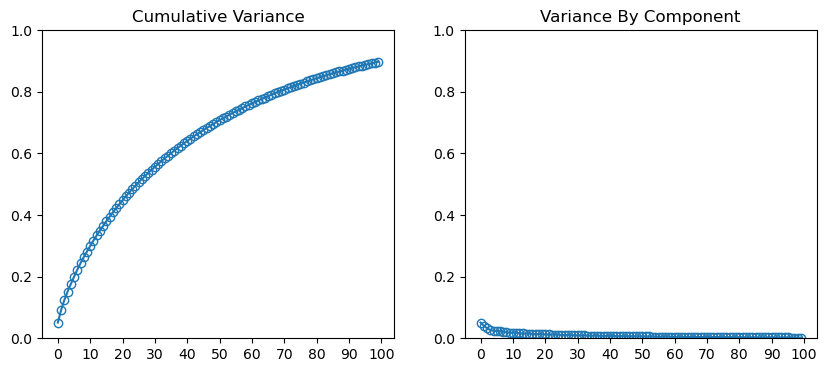

In [68]:
p, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(np.cumsum(pca.explained_variance_ratio_), marker="o", markerfacecolor="none")
axes[0].set_ylim((0, 1))
axes[0].set_title("Cumulative Variance")
_ = axes[0].set_xticks(np.arange(0, 105, 10))


axes[1].plot(pca.explained_variance_ratio_, marker="o", markerfacecolor="none")
axes[1].set_ylim((0, 1))
axes[1].set_title("Variance By Component")
_ = axes[1].set_xticks(np.arange(0, 105, 10))

In [69]:
df_ooo_qs.head()

,pid,participant_id_model,dim1,dim2,dim3,dim4,dim5,dim6,dim7,dim8,dim9,dim10,dim11,dim12,dim13,dim14,dim15,dim16,dim17,dim18,dim19,dim20,dim21,dim22,dim23,dim24,dim25,dim26,dim27,dim28,dim29,dim30,dim31,dim32,dim33,dim34,dim35,avg_weight,participant_id,session_id,Sex_0,age,edu,idx,income_0,motivation_1,rt,Extraversion,Agreeableness,Conscientiousness,Negative_Emotionality,Open_Mindedness,Negative Affect,Detachment,Antagonism,Disinhibition,Psychoticism,Impulsivity,embedding_work_history,embedding_interests1,embedding_interests2,embedding_interests3,embedding_all_txt,weights_delta_abs_sum,gini_overall,gini_first_half,gini_second_half,gini_delta,age_bin
0,1,779,0.208362,0.004599,0.017172,1.203313,0.015054,7.016681e-01,0.016407,1.119412,0.705151,0.751251,1.297134,0.696361,1.560730,1.001379,0.897733,0.989930,0.016550,1.187075,0.009665,1.284100,0.911404,0.475710,0.609050,0.014155,0.641545,0.919985,0.014856,0.615699,0.004275,1.785776,0.690326,1.032226,0.016520,0.130117,0.019925,0.616132,1.0,1.0,0.0,20.0,16.0,1.0,1.0,100.0,9503.536364,1.833333,3.833333,3.666667,2.000000,2.833333,1.8,0.2,0.0,0.2,0.0,1.875,"[0.045462742, -3.7966158e-05, -0.03360616, -0....","[0.04434629, -0.031788293, -0.028508278, -0.02...","[0.057681974, -0.026387516, -0.03254934, -0.02...","[0.017782766, -0.021664973, -0.027269462, -0.0...","[0.060353495, -0.034698877, -0.040745936, -0.0...",2.850439,0.680643,0.274160,0.242062,-0.032099,0
1,2,780,0.647656,1.216650,0.810587,0.883530,0.365455,5.261412e-01,1.342715,1.129191,0.027212,0.754328,1.450507,1.690352,2.383957,1.035591,0.553821,1.334707,1.263386,1.055957,0.264919,1.925055,1.614863,1.176456,1.144962,0.245082,1.221490,1.212661,0.790769,0.010393,0.867082,2.262787,0.541472,1.278065,0.716368,1.165210,0.722593,1.018056,2.0,1.0,0.0,24.0,12.0,2.0,6.0,71.0,7275.997727,1.666667,3.333333,2.333333,3.000000,3.000000,1.8,1.0,0.4,1.0,1.8,2.250,"[0.022140455, -0.016917942, -0.030119902, -0.0...","[0.039811797, -0.027577983, -0.011008029, -0.0...","[0.05039401, -0.025721, -0.021798655, -0.04201...","[0.025904825, -0.019225564, -0.021360084, -0.0...","[0.040389217, -0.037049606, -0.028004475, -0.0...",0.720537,0.224353,0.101085,0.106148,0.005064,1
2,3,781,0.015349,1.170435,0.886741,1.062732,1.150282,5.190409e-01,0.731418,0.016158,0.336044,1.128084,1.080724,1.698772,1.847218,0.965721,0.489272,0.963108,0.394114,0.866162,0.130998,1.376764,1.019884,0.705557,0.484516,0.016084,1.267052,0.347104,0.074547,0.811209,1.026741,1.595012,0.773042,1.876543,0.619601,0.851051,0.062456,0.810273,3.0,1.0,0.0,60.0,14.0,3.0,6.0,100.0,6308.461364,1.833333,2.666667,3.000000,0.500000,1.666667,0.8,2.0,0.2,0.2,1.4,1.000,"[0.031940643, -0.019540787, -0.032565124, -0.0...","[0.042537317, -0.027553733, -0.012717234, -0.0...","[0.031871993, -0.02153449, -0.018070221, -0.03...","[0.008142795, -0.018667512, -0.023717307, -0.0...","[0.033465814, -0.0398559, -0.030932011, -0.023...",1.158592,0.261099,0.103089,0.095590,-0.007500,3
3,5,782,0.649081,0.877286,0.807982,0.000469,0.279269,1.494513e-02,0.431213,1.140231,1.190000,0.021242,0.894193,0.895539,2.131896,0.011836,0.819911,1.244863,0.972013,0.498886,0.544478,1.207944,0.027504,0.000020,0.059533,0.025211,0.955352,0.391352,0.397120,0.768273,0.499678,1.489438,0.024879,1.039027,0.448591,0.899695,0.518108,0.633630,5.0,1.0,1.0,32.0,18.0,4.0,3.0,100.0,4575.063636,2.333333,3.833333,3.833333,0.166667,3.166667,0.2,0.0,0.4,0.0,0.4,0.875,"[0.01617315, -0.017961107, -0.016599972, -0.02...","[0.03898139, -0.029187014, -0.013460362, -0.02...","[0.039337512, -0.030673211, -0.017851807, -0.0...","[0.015296087, -0.015752321, -0.031320646, -0.0...","[0.02177569, -0.03686876, -0.024230763, -0.022...",3.648788,0.428195,0.089033,0.206850,0.117817,2
4,6,783,1.238885,1.210711,0.200016,1.095716,0.410824,6.758486e-09,1.140466,1.144044,1.391354,1.367254,1.367612,0.307775,2.209739,1.012134,1.201637,1.230317,0.019884,0.540698,0.016015,1.626909,1.061016,0.854451,0.351884,1.179763,1.111666,1.194901,1.047083,0.014221,0.680422,0.878200,1.124101,1.

In [70]:
def predict_holdout_ooo(pid, ndim_pca):
    
    # select the data to be learned upon
    df_map = df_ooo_qs.query(f"""pid != {pid}""").copy()
    m_text_embedding =  np.vstack(df_map["embedding_all_txt"].to_numpy())
    m_ooo_embedding = df_map[colnames_dim_weights_full].to_numpy()
    
    # select the to-be predicted data
    df_predict = df_ooo_qs.query(f"""pid == {pid}""").copy()
    X_new = np.array(df_predict[colnames_dim_weights_full])
    Y_new = df_predict["embedding_all_txt"].to_numpy()[0]
    
    # project to lower-dim. space
    pca = PCA(n_components=ndim_pca)
    pca_result = pca.fit_transform(scaled_data)
    
    # learn mapping
    model = RandomForestRegressor()
    model.fit(pca_result, m_ooo_embedding)
    
    # generate predictions on hold-out data
    Y_new_scaled = z_scaler_text.transform(Y_new.reshape(1, -1))
    Y_new_pca = pca.transform(Y_new_scaled)
    ooo_pred = model.predict(Y_new_pca)
    
    # compute the metric to evaluate
    target = df_ooo_qs[["pid"] + colnames_dim_weights_full].query(f"""pid == {pid}""")[colnames_dim_weights_full].to_numpy()
    diff = ooo_pred - target
    diff_abs = np.abs(diff).sum(axis=1)

    pred_heuristic = df_ooo_qs[colnames_dim_weights_full].mean(axis=0).to_numpy()
    diff_heuristic = pred_heuristic - target
    diff_abs_heuristic = np.abs(diff_heuristic).sum(axis=1)
    
    df_pred = pd.DataFrame({
        "pid": pid,
        "true": target.reshape(-1),
        **{f"ooo_pred_{i}": o for i, o in enumerate(ooo_pred)}
    }).reset_index().rename(columns={"index":"Dimension"})

    return df_pred, diff_abs, diff_abs_heuristic

In [71]:
pid = 1
ndim_pca = 30
ooo_pred, diff_abs, diff_abs_heuristic = predict_holdout_ooo(pid, ndim_pca)

In [72]:
use_filter = [i not in [82, 148] for i in l_pids_new]

In [73]:
l_pids_new_filtered = [idx for idx, filt in zip(l_pids_new, use_filter) if filt]

In [74]:
def extract_diff(x):
    return x[1]

def extract_diff_heuristic(x):
    return x[2]
    
def pipe_loo_pca(ndim_pca):  
    partial_predict = partial(predict_holdout_ooo, ndim_pca=ndim_pca)
    l_results = list(map(partial_predict, l_pids_new_filtered))
    l_diffs = list(map(extract_diff, l_results))
    l_diffs_heuristic = list(map(extract_diff_heuristic, l_results))
    df_compare = pd.DataFrame({"ndim_pca":ndim_pca, "diff":np.array(l_diffs).reshape(-1), "diff_heuristic":np.array(l_diffs_heuristic).reshape(-1)})
    df_out = df_compare.groupby("ndim_pca").mean()

    return df_out

In [75]:
l_pca_dims = [10, 30, 50, 70, 90]

In [76]:
from concurrent.futures import ThreadPoolExecutor

with ThreadPoolExecutor(os.cpu_count() - 2) as executor:
    l_results_loo_pca = list(executor.map(pipe_loo_pca, l_pca_dims))

In [85]:
df_compare = reduce(lambda x, y: pd.concat([x, y]), l_results_loo_pca)

In [86]:
df_compare.to_pickle("data/dataframes-plotting-ms/text-weights-mapping.pkl")

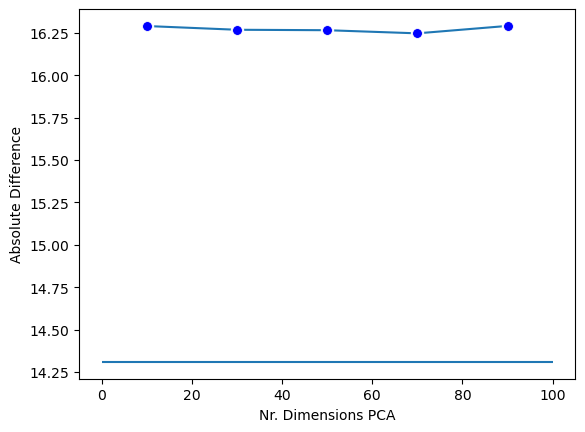

In [87]:
fig, ax = plt.subplots(1)

sns.lineplot(data=df_compare.reset_index(), x="ndim_pca", y="diff", ax=ax, zorder=1)
sns.scatterplot(data=df_compare.reset_index(), x="ndim_pca", y="diff", ax=ax, color='white', s=80, zorder=2)
sns.scatterplot(data=df_compare.reset_index(), x="ndim_pca", y="diff", ax=ax, color='blue', s=50, zorder=3)
ax.set_xlabel("Nr. Dimensions PCA")
ax.set_ylabel("Absolute Difference")
_ = ax.hlines(y=df_compare.iloc[0, 1], xmin=0, xmax=100)

could be run as a pipeline with loo cv, such that one participant is excluded, their ooo weights are predicted, their choices on the ooo task are predicted as well, and then compared to, for example, the weights of the remaining participants

## What content do the dimensions code for?

l_data_subset = ["full"]
l_rnd_seed = [15]
l_embed_dim = [10]
modeltype = "free_weights_no_scaling"
modelversion = "embeddings-decision-combined-data"

# load results from model run
l_results_full = ut.load_ID_lowdim(
    l_data_subset=l_data_subset, l_rnd_seed=l_rnd_seed, 
    l_embed_dim=l_embed_dim, modelversion=modelversion, modeltype=modeltype
)

In [69]:
df_embeddings_full = pd.DataFrame(l_results_full[idx_full]["item_embeddings"].detach().numpy().transpose()).reset_index()
df_embeddings_full.columns = ["image_id"] + [i for i in range(0, l_embed_dim[0])]

In [70]:
import re
l_concepts = os.listdir("data/images/")
l_m = [re.match("^[a-z]", l_concepts[i]) for i in range(0, len(l_concepts))]
l_filter = [l_m[i] != None for i in range(0, len(l_concepts))]
l_concepts_filtered = [value for value, flag in zip(l_concepts, l_filter) if flag]
f_partial = partial(ut.extract_image, l_concepts_filtered)

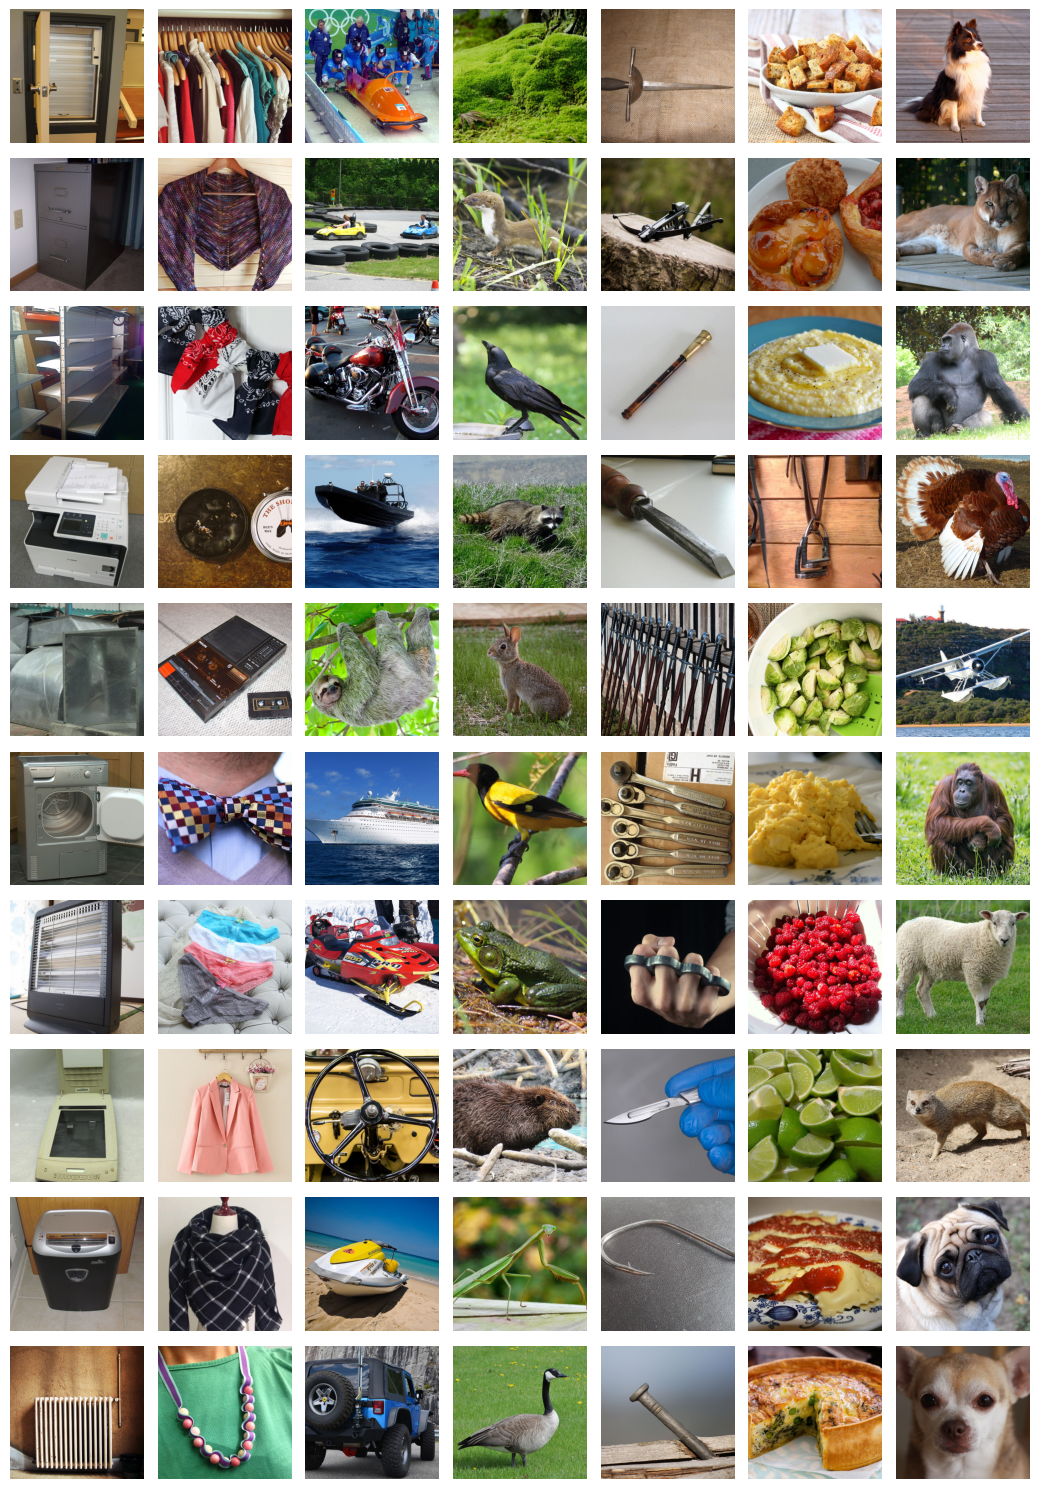

In [71]:
# Normalize correlation to [0, 1] for size scaling
n_images_plot = 10

f, axes = plt.subplots(
    n_images_plot, l_embed_dim[0], 
    figsize=(l_embed_dim[0] * 1.5, n_images_plot * 1.5)
)

for current_dim in range(0, l_embed_dim[0]):
    
    lot_coded = df_embeddings_full[["image_id", current_dim]].sort_values(current_dim, ascending=False).reset_index(drop=True)
    
    l_ids_lot_coded = lot_coded.loc[0:(n_images_plot-1), "image_id"]
    paths_lot_coded = list(map(f_partial, l_ids_lot_coded))
    
    for j in range(n_images_plot):
        img = Image.open(paths_lot_coded[j])
        axes[j, current_dim].imshow(img)
        axes[j, current_dim].axis("off")
        
plt.tight_layout()

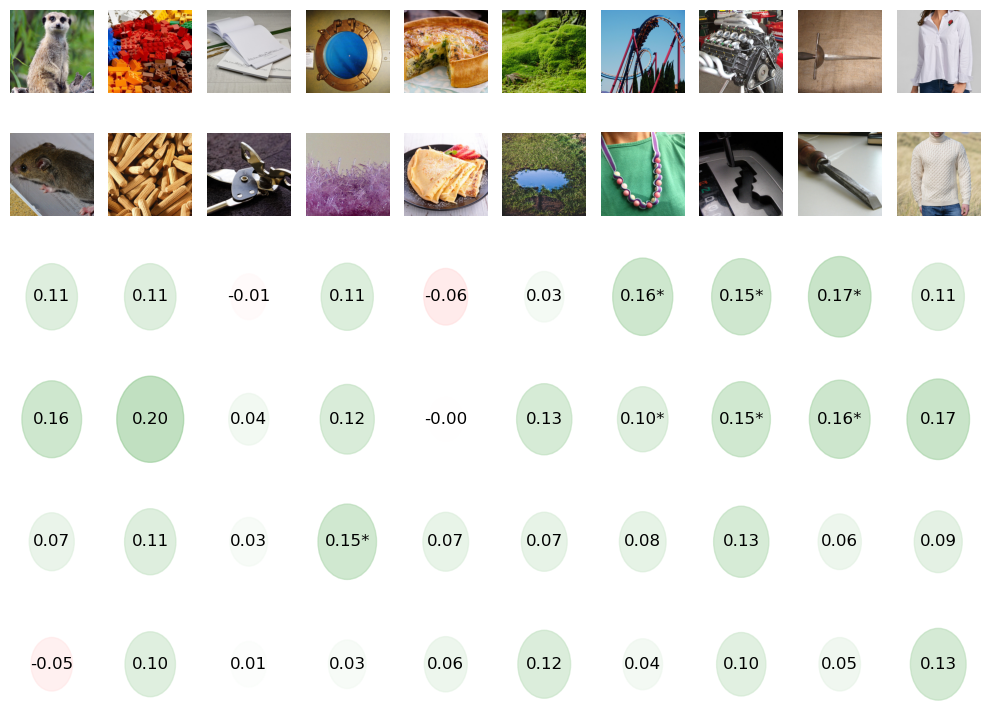

In [170]:
# Custom normalization from -1 to 1
norm = mcolors.Normalize(vmin=-.5, vmax=.5)

# Create diverging colormap: red → white → green
cmap = mcolors.LinearSegmentedColormap.from_list("custom_corr", ["red", "white", "green"])

# Normalize correlation to [0, 1] for size scaling
n_images_plot = 2
size = abs(df_max_corrs.query("Variable == 'Age'")["r"]) * 1000

f, axes = plt.subplots(
    n_images_plot + 4,l_embed_dim[0], 
    figsize=((l_embed_dim[0]), (n_images_plot + 4) * 1.25)
)

for current_dim in range(0, l_embed_dim[0]):
    
    lot_coded = df_embeddings_full[["image_id", current_dim]].sort_values(current_dim, ascending=False).reset_index(drop=True)
    
    l_ids_lot_coded = lot_coded.loc[0:(n_images_plot-1), "image_id"]
    paths_lot_coded = list(map(f_partial, l_ids_lot_coded))
    
    for j in range(n_images_plot):
        img = Image.open(paths_lot_coded[j])
        axes[j, current_dim].imshow(img)
        axes[j, current_dim].axis("off")

    corr_age = df_max_corrs.query("Variable == 'Age'")["r"].reset_index(drop=True)[current_dim]
    sig_age = df_max_corrs.query("Variable == 'Age'")["pvalue"].reset_index(drop=True)[current_dim]
    # Get color from colormap
    color_age = cmap(norm(corr_age))
    circle = patches.Circle((0.5, 0.5), radius=0.2 + abs(corr_age), color=color_age, alpha=0.6)
    axes[n_images_plot, current_dim].add_patch(circle)
    axes[n_images_plot, current_dim].set_xlim(0, 1)
    axes[n_images_plot, current_dim].set_ylim(0, 1)
    if sig_age <= 0.05:
        axes[n_images_plot, current_dim].text(0.5, 0.5, f"{corr_age:.2f}*", ha='center', va='center', fontsize=12)
    else:
        axes[n_images_plot, current_dim].text(0.5, 0.5, f"{corr_age:.2f}", ha='center', va='center', fontsize=12)
    axes[n_images_plot, current_dim].axis("off")

    corr_motivation = df_max_corrs.query("Variable == 'Motivation (Self Report)'")["r"].reset_index(drop=True)[current_dim]
    sig_motivation = df_max_corrs.query("Variable == 'Motivation (Self Report)'")["pvalue"].reset_index(drop=True)[current_dim]
    
    # Get color from colormap
    color_motivation = cmap(norm(corr_motivation))
    circle = patches.Circle((0.5, 0.5), radius=0.2 + abs(corr_motivation), color=color_motivation, alpha=0.6)
    axes[n_images_plot+1, current_dim].add_patch(circle)
    axes[n_images_plot+1, current_dim].set_xlim(0, 1)
    axes[n_images_plot+1, current_dim].set_ylim(0, 1)
    if sig_age <= 0.05:
        axes[n_images_plot+1, current_dim].text(0.5, 0.5, f"{corr_motivation:.2f}*", ha='center', va='center', fontsize=12)
    else:
        axes[n_images_plot+1, current_dim].text(0.5, 0.5, f"{corr_motivation:.2f}", ha='center', va='center', fontsize=12)
    
    axes[n_images_plot+1, current_dim].axis("off")

    corr_edu = df_max_corrs.query("Variable == 'Years Education'")["r"].reset_index(drop=True)[current_dim]
    sig_edu = df_max_corrs.query("Variable == 'Years Education'")["pvalue"].reset_index(drop=True)[current_dim]
    # Get color from colormap
    color_detachment = cmap(norm(corr_edu))
    circle = patches.Circle((0.5, 0.5), radius=0.2 + abs(corr_edu), color=color_detachment, alpha=0.6)
    axes[n_images_plot+2, current_dim].add_patch(circle)
    axes[n_images_plot+2, current_dim].set_xlim(0, 1)
    axes[n_images_plot+2, current_dim].set_ylim(0, 1)
    if sig_edu <= 0.05:
        axes[n_images_plot+2, current_dim].text(0.5, 0.5, f"{corr_edu:.2f}*", ha='center', va='center', fontsize=12)
    else:
        axes[n_images_plot+2, current_dim].text(0.5, 0.5, f"{corr_edu:.2f}", ha='center', va='center', fontsize=12)
    
    axes[n_images_plot+2, current_dim].axis("off")


    corr_gender = df_max_corrs.query("Variable == 'Gender (1: Women)'")["r"].reset_index(drop=True)[current_dim]
    sig_gender = df_max_corrs.query("Variable == 'Gender (1: Women)'")["pvalue"].reset_index(drop=True)[current_dim]
    # Get color from colormap
    color_detachment = cmap(norm(corr_gender))
    circle = patches.Circle((0.5, 0.5), radius=0.2 + abs(corr_gender), color=color_detachment, alpha=0.6)
    axes[n_images_plot+3, current_dim].add_patch(circle)
    axes[n_images_plot+3, current_dim].set_xlim(0, 1)
    axes[n_images_plot+3, current_dim].set_ylim(0, 1)
    if sig_gender <= 0.05:
        axes[n_images_plot+3, current_dim].text(0.5, 0.5, f"{corr_gender:.2f}*", ha='center', va='center', fontsize=12)
    else:
        axes[n_images_plot+3, current_dim].text(0.5, 0.5, f"{corr_gender:.2f}", ha='center', va='center', fontsize=12)
    
    axes[n_images_plot+3, current_dim].axis("off")
        
plt.tight_layout()

## compare dimensional importance for few vs. many dimensions

In [ ]:
l_data_subset = ["full"]
l_rnd_seed = [1]
l_embed_dim = [6]
modeltype = "free_weights_no_scaling"
modelversion = "embeddings-decision-combined-data"

# load results from model run
l_few = ut.load_ID_lowdim(
    l_data_subset=l_data_subset, l_rnd_seed=l_rnd_seed, 
    l_embed_dim=l_embed_dim, modelversion=modelversion, modeltype=modeltype
)
df_embeddings_full_few = pd.DataFrame(l_few[0]["decision_weights"].detach().numpy()).reset_index()
df_embeddings_full_few.columns = ["image_id"] + [i for i in range(0, l_embed_dim[0])]

In [ ]:
# compare with many more dimensions
modelversion = "avg-ID-jointly-embeddings"
l_n = [50]
l_temperature = [1.0]
l_subjecttype = ["subjects_actual"]
lmbda = [0.0005]
lmbda_hierarchical = [0.01]
rnd_seed = '998877'
l_sparse = ["items_and_random_ids"]
l_splithalf = ["no"]

l_many = ut.extract_results_id(
    lmbda, lmbda_hierarchical, rnd_seed, modelversion, l_n, l_sparse,
    l_subjecttype, l_splithalf, modeltype="random_weights",
    l_temperature=l_temperature
)
df_embeddings_full_many = pd.DataFrame(l_many[0]["model_state_dict"]["fc.weight"].detach().numpy().transpose()).reset_index()
df_embeddings_full_many.columns = ["image_id"] + [i for i in range(0, l_n[0])]

In [ ]:
l_embed_dim

In [ ]:
f, ax = plt.subplots(1)
l_prop_prop = []
for dim in range(0, l_embed_dim[0]):
    df_plt_prop = df_embeddings_full_few.copy()
    df_plt_prop[dim] = df_plt_prop[dim] / df_plt_prop[dim].max()
    df_plt_prop.sort_values(dim, inplace=True)
    df_plt_prop = df_plt_prop.reset_index(drop=True)
    l_prop_prop.append(df_plt_prop[dim])
    ax.plot(df_plt_prop.index/df_plt_prop.index.max(), df_plt_prop[dim], c="red", alpha=.75)
df_prop_prop = pd.DataFrame(l_prop_prop).transpose()
df_prop_prop["avg"] = df_prop_prop.mean(axis=1)
ax.plot(df_prop_prop["avg"].index/df_prop_prop.index.max(), df_prop_prop["avg"], c="red", linewidth=3, alpha=1, label="few")

l_prop_prop = []
for dim in range(0, 50):
    df_plt_prop = df_embeddings_full_many.copy()
    df_plt_prop[dim] = df_plt_prop[dim] / df_plt_prop[dim].max()
    df_plt_prop.sort_values(dim, inplace=True)
    df_plt_prop = df_plt_prop.reset_index(drop=True)
    l_prop_prop.append(df_plt_prop[dim])
    ax.plot(df_plt_prop.index/df_plt_prop.index.max(), df_plt_prop[dim], c="blue", alpha=.25)
df_prop_prop = pd.DataFrame(l_prop_prop).transpose()
df_prop_prop["avg"] = df_prop_prop.mean(axis=1)

ax.set_title(ax.get_title(), fontsize=16)
ax.set_xlabel("Prop. Items", fontsize=14)
ax.set_ylabel("Prop. Max. Value", fontsize=14)
ax.tick_params(axis='both', labelsize=12)
ax.grid(True)

_ = ax.plot(df_prop_prop["avg"].index/df_prop_prop.index.max(), df_prop_prop["avg"], c="blue", linewidth=3, alpha=.75, label="many")

_ = plt.legend()

In [ ]:
df_hist_many = pd.DataFrame(np.tril(np.corrcoef(df_embeddings_full_many.drop(columns="image_id").transpose()), k=-1))
df_hist_many = df_hist_many.reset_index().melt(id_vars="index").query("value > 0")

df_hist_few = pd.DataFrame(np.tril(np.corrcoef(df_embeddings_full_few.drop(columns="image_id").transpose()), k=-1))
df_hist_few = df_hist_few.reset_index().melt(id_vars="index").query("value > 0")

fig, ax = plt.subplots(1)

sns.histplot(df_hist_few, x="value", bins=30, stat="probability", ax=ax, color="red", label="few")
sns.histplot(df_hist_many, x="value", bins=30, stat="probability", ax=ax, color="blue", label="many")

ax.set_ylim(0, .7)
ax.legend()
ax.set_title(ax.get_title(), fontsize=16)
ax.set_xlabel("Correlation", fontsize=14)
ax.set_ylabel("Proportion", fontsize=14)
ax.tick_params(axis='both', labelsize=12)
ax.grid(True)
ax.set_title("Pairwise Correlations Between Dimensions")
_ = ax.set_xlim((0, 1))